In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv("../data/Superstore.csv",encoding='latin1')

In [31]:
#checking missing values
df.isnull().sum() #no missing values are found in datasets

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [32]:
#checking duplicate rows 
df.duplicated().sum() #no duplicates rows are present in datasets

np.int64(0)

In [33]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [34]:
df['Order Date'] = pd.to_datetime(df['Order Date']) #converting date to datetime

In [35]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [36]:
df.dtypes #converted into datetime

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

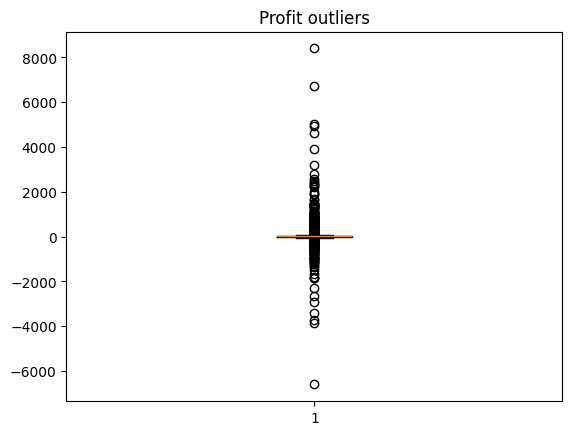

In [37]:
plt.boxplot(df['Profit']) #outliers detected in profit using boxplot
plt.title("Profit outliers")
plt.show()

In [38]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(len(outliers))

1167


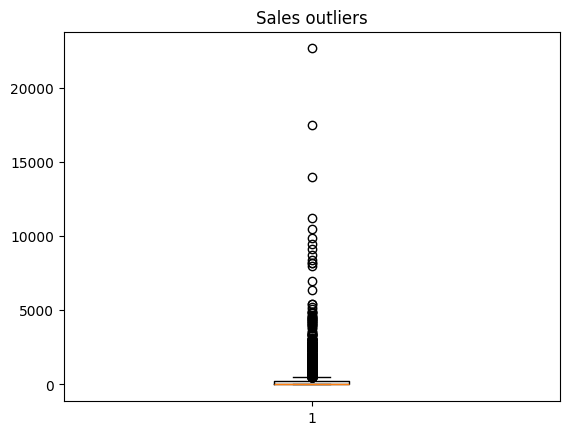

In [39]:
plt.boxplot(df['Sales']) #outliers detected in sales using boxplot
plt.title("Sales outliers")
plt.show()

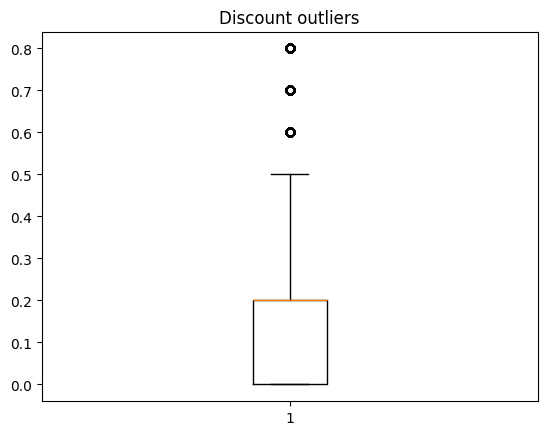

In [40]:
plt.boxplot(df['Discount']) #outliers detected in Discount using boxplot
plt.title("Discount outliers")
plt.show()

In [41]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]
print(len(outliers))

170


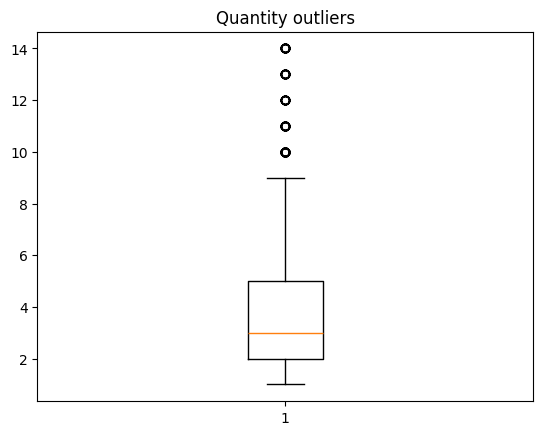

In [42]:
plt.boxplot(df['Quantity']) #outliers detected in Quantity using boxplot
plt.title("Quantity outliers")
plt.show()

In [43]:
# Handle outliers by capping the values at the upper and lower bounds
df['Sales'] = df['Sales'].clip(lower_bound, upper_bound)
df['Quantity'] = df['Quantity'].clip(lower_bound, upper_bound)


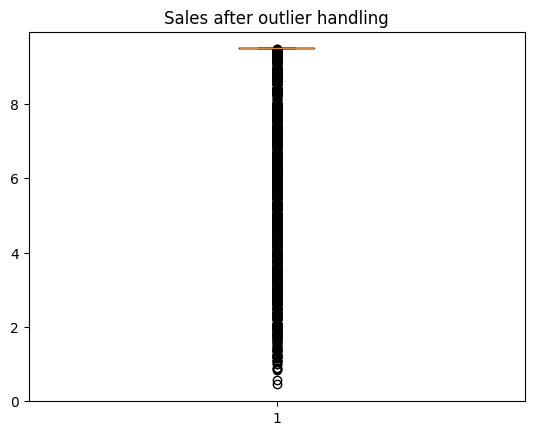

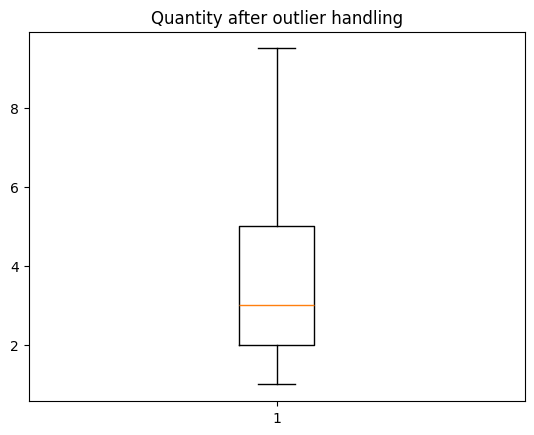

In [44]:
# After handling outliers, we can visualize the boxplots again to confirm that the outliers have been addressed
plt.boxplot(df['Sales'])
plt.title("Sales after outlier handling")
plt.show()

plt.boxplot(df['Quantity'])
plt.title("Quantity after outlier handling")
plt.show()

In [45]:
# STEP 1: Find all loss-making records

loss_making_records = df[df['Profit'] < 0]
print(loss_making_records)

      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
3          4  US-2015-108966 2015-10-11 2015-10-18  Standard Class   
14        15  US-2015-118983 2015-11-22 2015-11-26  Standard Class   
15        16  US-2015-118983 2015-11-22 2015-11-26  Standard Class   
23        24  US-2017-156909 2017-07-16 2017-07-18    Second Class   
27        28  US-2015-150630 2015-09-17 2015-09-21  Standard Class   
...      ...             ...        ...        ...             ...   
9920    9921  CA-2016-149272 2016-03-15 2016-03-19  Standard Class   
9921    9922  CA-2014-111360 2014-11-24 2014-11-30  Standard Class   
9931    9932  CA-2015-104948 2015-11-13 2015-11-17  Standard Class   
9937    9938  CA-2016-164889 2016-06-03 2016-06-06    Second Class   
9962    9963  CA-2015-168088 2015-03-19 2015-03-22     First Class   

     Customer ID     Customer Name      Segment        Country  \
3       SO-20335    Sean O'Donnell     Consumer  United States   
14      HP-14815     Harold

In [46]:
# How much loss overall?

total_loss = loss_making_records['Profit'].sum()
print(f"Total loss: {total_loss}")


# Category-wise loss

category_loss = loss_making_records.groupby('Category')['Profit'].sum()
print("\nCategory-wise loss:\n", category_loss)


# Sub-category-wise loss

subcategory_loss = loss_making_records.groupby('Sub-Category')['Profit'].sum()
print("\nSub-category-wise loss:\n", subcategory_loss)


# Region-wise loss

region_loss = loss_making_records.groupby('Region')['Profit'].sum()
print("\nRegion-wise loss:\n", region_loss)

Total loss: -156131.2857

Category-wise loss:
 Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64

Sub-category-wise loss:
 Sub-Category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: Profit, dtype: float64

Region-wise loss:
 Region
Central   -56314.8850
East      -49590.6075
South     -27504.8323
West      -22720.9609
Name: Profit, dtype: float64


In [47]:
# STEP 6: Discount impact (ROOT CAUSE)

discount_impact = loss_making_records.groupby('Discount')['Profit'].sum()
print("\nDiscount impact on loss:\n", discount_impact)


Discount impact on loss:
 Discount
0.10      -29.2744
0.15     -328.7030
0.20   -17258.0654
0.30   -10777.6879
0.32    -2391.1377
0.40   -25787.8268
0.45    -2493.1111
0.50   -20506.4281
0.60    -5944.6552
0.70   -40075.3569
0.80   -30539.0392
Name: Profit, dtype: float64


Text(0.5, 1.0, 'Discount vs Profit')

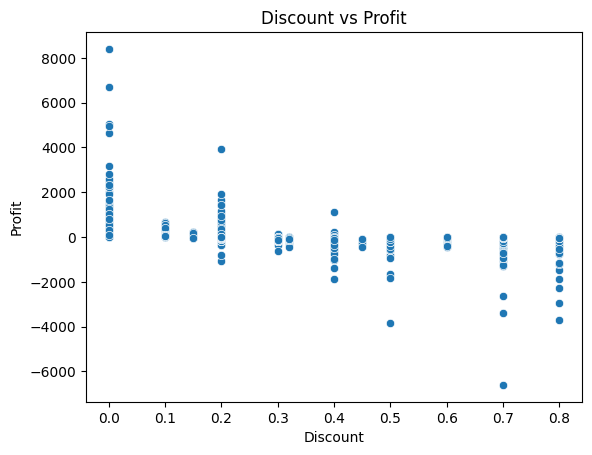

In [49]:
# Viualize the relationship between Discount and Profit

import seaborn as sns

sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")

Text(0.5, 1.0, 'Sales vs Profit')

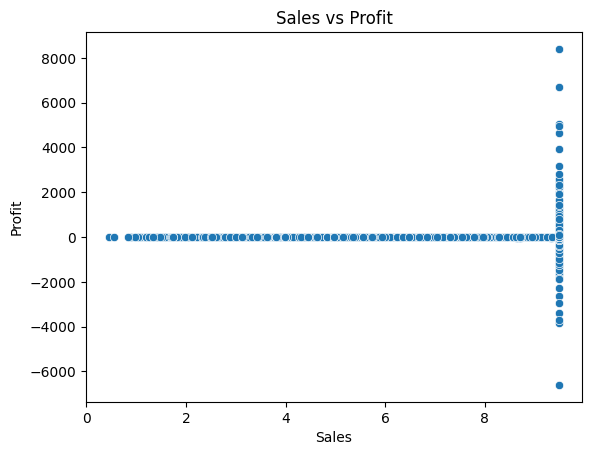

In [50]:
# Compare Sales vs Profit

sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")